## Agentic RAG implementations using LangGraph

```mermaid
flowchart TD
    start([__start__]) --> agent

    agent -.-> retrieve
    agent -.-> generate

    tools -.-> retrieve

    retrieve -.-> rewrite
    retrieve -.-> generate

    rewrite -.-> agent

    generate --> stop([__end__])

    subgraph left [ ]
        tools
        retrieve
        rewrite
    end

    style start fill:#ddd,stroke:#999,color:#000
    style stop fill:#c9b8e8,stroke:#9b8ec4,color:#000
    style agent fill:#c9b8e8,stroke:#9b8ec4,color:#000
    style retrieve fill:#c9b8e8,stroke:#9b8ec4,color:#000
    style rewrite fill:#c9b8e8,stroke:#9b8ec4,color:#000
    style generate fill:
```

In [32]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [33]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

In [51]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools.retriever import create_retriever_tool
from typing import Annotated, Sequence, TypedDict, Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Markdown, display

### Create the retriver tool with information about LangGraph

In [35]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())

In [36]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 100
)

doc_splits = text_splitter.split_documents(docs)

In [37]:
doc_splits[:2]

[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [38]:
vector_store = FAISS.from_documents(
    doc_splits,
    OpenAIEmbeddings()
)

In [39]:
retriever = vector_store.as_retriever()

In [40]:
retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and Run information about LangGraph"
)

### Create retriever tool with information about langchain

In [41]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs = []
for url in langchain_urls:
    docs.extend(WebBaseLoader(url).load())

In [42]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 100
)

doc_splits = text_splitter.split_documents(docs)

vector_store = FAISS.from_documents(
    doc_splits,
    OpenAIEmbeddings()
)

retriever_langchain = vector_store.as_retriever()

In [43]:
retriever_tool_langchain=create_retriever_tool(
    retriever_langchain,
    "retriever_vector_langchain_blog",
    "Search and run information about Langchain"
)

In [44]:
tools=[retriever_tool,retriever_tool_langchain]

### LangGraph Workflow

In [45]:
class AgentState(TypedDict):

    messages: Annotated[Sequence[BaseMessage], add_messages]

In [53]:
def agent(state:AgentState):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """

    print("---CALL AGENT---")
    messages = state['messages']
    llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.6)
    llm_with_tools = llm.bind_tools(tools=tools)
    response = llm_with_tools.invoke(messages)

    return {"messages": [response]}

In [54]:
class grade(BaseModel):
    """Binary score for Relavance Check"""
    binary_score: str = Field("Relavance score 'yes' or 'no'.")

# conditional edge function: with strict output 
def grade_documents(state:AgentState) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """
    print("---CHECK RELAVANCE---")
    llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.6)
    llm_structured = llm.with_structured_output(grade)

    prompt = PromptTemplate(
        template = """
    You are a grader assessing relevance of a retrieved document to a user question. \n
    Here is the retrieved document: \n\n {context} \n\n
    Here is the user question: {question} \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """,
    input_variables=["context", "question"]
    )

    chain = prompt|llm_structured

    messages = state["messages"]

    docs = messages[-1].content
    question = messages[0].content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"
    else:
        print("---DECISION:DOCS NOT RELEVANT---")
        return "rewrite"


In [55]:
def generate(state: AgentState):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]

    question = messages[0].content
    docs = messages[-1].content

    prompt = PromptTemplate(
        template="""
        You are an assistant for question-answering tasks. 
        Use the following pieces of retrieved context to answer the question. 
        If you don't know the answer, just say that you don't know. 
        Use three sentences maximum and keep the answer concise.

        Question: {question} 
        Context: {context} 
        Answer:
        """,
        input_variables=['question', 'context']
    )

    llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.6)
    rag_chain = prompt|llm|StrOutputParser()

    response = rag_chain.invoke({"question": question, "context": docs})

    return {"messages": [response]}

In [56]:
def rewrite(state: AgentState):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    llm = ChatGroq(model="qwen/qwen3-32b", temperature=0.6)
    response = llm.invoke(msg)
    return {"messages": [response]}

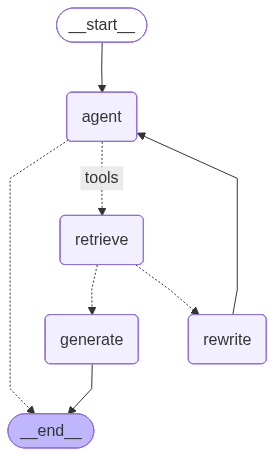

In [57]:
# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode(tools = [retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node("generate", generate)

# Edges
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [58]:
results = graph.invoke({"messages":"What is Langgraph?"})
display(Markdown(results['messages'][-1].content))

---CALL AGENT---
---CHECK RELAVANCE---
---DECISION:DOCS NOT RELEVANT---
---TRANSFORM QUERY---
---CALL AGENT---
---CHECK RELAVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


<think>
Okay, the user is asking, "What is Langgraph?" Let me look through the provided context to find the answer.

First, in the context, there's a section titled "LangChain overview" which mentions LangGraph. It says, "LangChain’s agents are built on top of LangGraph." So LangGraph is part of the LangChain framework.

Then, under the "LangChain vs. LangGraph vs. Deep Agents" section, it states: "Use LangGraph, our low-level agent orchestration framework and runtime, when you have more advanced needs..." This indicates that LangGraph is a lower-level framework used for agent orchestration.

Additionally, the context mentions that LangGraph provides durable execution, human-in-the-loop support, and persistence. So, LangGraph serves as the underlying framework for LangChain agents, allowing for customization and advanced workflows.

Putting this together, LangGraph is a low-level framework that LangChain uses to build agents. It's designed for more advanced users who need customization and complex workflows. The answer should mention that LangGraph is an orchestration framework, part of the LangChain ecosystem, and used for building and managing agents with advanced features.
</think>

LangGraph is a low-level agent orchestration framework and runtime within the LangChain ecosystem. It enables durable execution, human-in-the-loop support, and customization for advanced workflows. LangChain agents are built on top of LangGraph, providing flexibility for complex agent architectures.

In [59]:
results = graph.invoke({"messages":"What is LangChain?"})
display(Markdown(results['messages'][-1].content))

---CALL AGENT---
---CHECK RELAVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


<think>
Okay, let's see. The user is asking what LangChain is. I need to use the provided context to answer this.

Looking at the context, there's a section titled "LangChain overview" which says LangChain is an open-source framework with a prebuilt agent architecture and integrations for any model or tool. It allows building agents that adapt quickly. Also mentioned are core benefits like a standard model interface, easy-to-use agents, being built on LangGraph, and debugging with LangSmith. The context also compares LangChain with LangGraph and Deep Agents, suggesting LangChain is a good starting point for building custom agents.

I should focus on the key points: open-source, framework for building agents, integrations with models/tools, easy to use, flexibility. Need to mention it's built on LangGraph and offers debugging via LangSmith. But keep it concise, three sentences max. Avoid technical jargon where possible. Make sure not to include information that's not directly relevant, like specific comparisons unless necessary. Check if there's any other important info, like the line about connecting to OpenAI, Anthropic, etc., but maybe that's part of the integrations. The answer should be clear and to the point.
</think>

LangChain is an open-source framework for building agents and applications with large language models (LLMs), offering prebuilt architectures and integrations for seamless model and tool connectivity. It provides a standardized interface for different providers, enabling flexibility and easy customization through its agent abstraction. Built on LangGraph, it supports durable execution, human-in-the-loop workflows, and debugging via LangSmith.

In [60]:
results = graph.invoke({"messages":"What is Deep Learning?"})
display(Markdown(results['messages'][-1].content))

---CALL AGENT---


The provided tools are designed to search for information related to LangGraph and Langchain, which are specific frameworks or projects. Since your question about "Deep Learning" is a general machine learning concept and not specific to those frameworks, I cannot use the provided tools to retrieve an answer. However, I can explain that Deep Learning is a subset of machine learning involving neural networks with multiple layers to model complex patterns in data. Would you like further clarification?